<a href="https://colab.research.google.com/github/kintama285/test/blob/main/11_jurnal_k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Lembar Kerja Praktikum:**
* Mata Kuliah :BDDM
* Pertemuan Ke : 22
* CPMK: Mahasiswa Mampu Menerapkan Metode Analisis Data (CPMK 21)
* Sub CPMK: Mahasiswa dapat menjelaskan konsep dasar dan cara kerja algoritma clustering (un-supervised learning) (SCPMK 1682111)
* Indikator Keberhasilan: Mahasiswa penyelesaian contoh kasus clustering dalam bahasa pemrograman

### **Identitas Praktikan:**
* Nama: Reyvandi Iqbal Maulana
* Nim: 23.11.5650
* Kelas: BigData1

### **Petunjuk Praktikum:**
* LINK DATASET: https://s.amikom.ac.id/DATASET-MALLCUSTOMER

### **K Means**
Metode K-means merupakan metode clustering yang paling sederhana dan umum. Hal ini dikarenakan K-means mempunyai kemampuan mengelompokkan data dalam jumlah yang cukup besar dengan waktu komputasi yang cepat dan efisien.

**Inertia** mengukur seberapa dekat data-data dalam satu cluster terhadap centroid-nya.


*   Semakin kecil nilai inertia → cluster semakin rapat dan homogen, cluster semakin baik
*   Semakin besar nilai inertia → cluster semakin menyebar & hasil cluster kurang baik




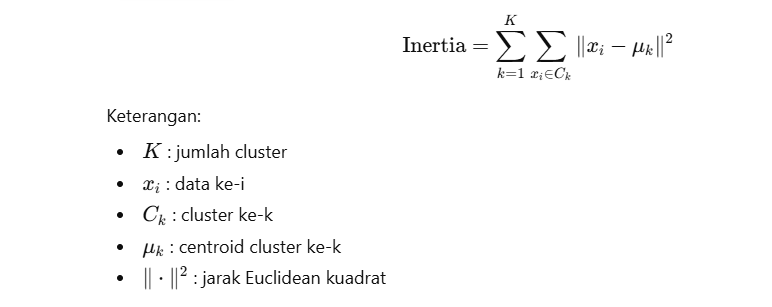

**WCSS (Within-Cluster Sum of Squares)** adalah ukuran kekompakan cluster pada algoritma clustering (terutama K-Means).
WCSS menghitung total jarak kuadrat antara setiap data dan centroid cluster tempat data tersebut berada.

**WCSS** mengukur seberapa rapat data di dalam masing-masing cluster.
Semakin kecil nilai WCSS → cluster semakin kompak.

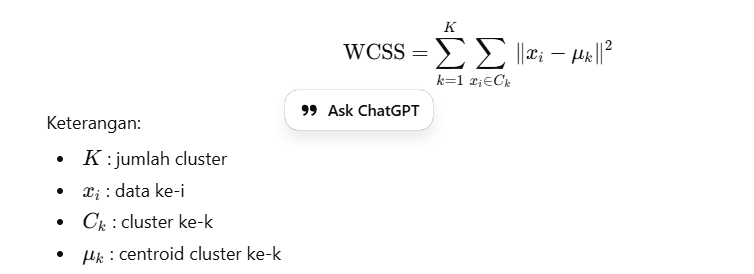

Elbow method: titik di mana penurunan WCSS mulai melambat(titik siku)

**Silhouette Score** adalah metrik evaluasi clustering yang mengukur seberapa baik setiap data ditempatkan di dalam cluster-nya dengan mempertimbangkan kekompakan (within-cluster) dan pemisahan (between-cluster).

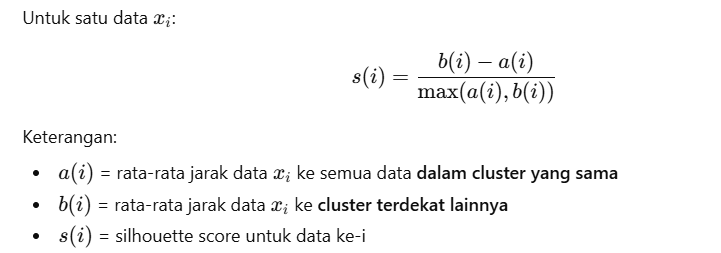

### **1. Import Library**



In [ ]:
import numpy as np
import pandas as pd

# Visualization packages
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Determine number of clusters
from sklearn.metrics import silhouette_score

### **2. Load Dataset**

In [ ]:
df = pd.read_csv('/content/sample_data/Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### **3. Visualisasi Data**

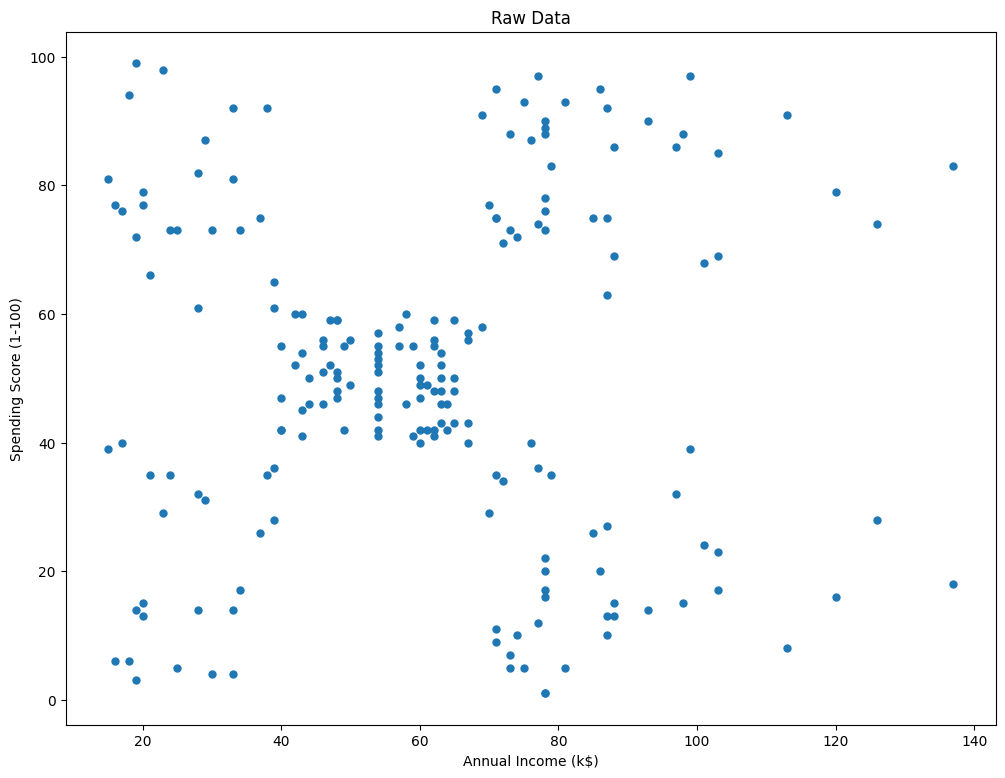

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], s = 25) #Point size is 25
plt.title('Raw Data')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

### **4. Data Preprocessing**

feature selection

In [ ]:
X = np.array(df.iloc[:,[3,4]])

In [ ]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

### **5. Create Cluster**

In [ ]:
kmeans = KMeans(n_clusters = 5, max_iter = 500, n_init = 10, random_state = 0)
kmeans_preds = kmeans.fit_predict(X)

In [ ]:
#predict result
kmeans_preds

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [88.2        17.11428571]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]]


In [ ]:
print("Inertia:", kmeans.inertia_)

Inertia: 44448.45544793369


In [ ]:
kmeans1 = KMeans(n_clusters = 5, max_iter = 500, n_init = 1, random_state = 0)
kmeans_preds1 = kmeans1.fit_predict(X)

In [ ]:
#predict result
kmeans_preds1

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 4, 4, 4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 0, 4,
       4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 4, 4, 4, 0, 0, 4, 0, 4, 4, 4, 4, 4,
       4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 4, 0, 0,
       0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 1, 4, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans1.cluster_centers_)

[[54.06       40.46       36.72      ]
 [32.69230769 86.53846154 82.12820513]
 [25.25       25.83333333 76.91666667]
 [41.64705882 88.73529412 16.76470588]
 [33.39622642 58.05660377 48.77358491]]


In [ ]:
print("Inertia:", kmeans.inertia_)

Inertia: 58300.443321590676


In [ ]:
kmeans20 = KMeans(n_clusters = 5, max_iter = 500, n_init = 20, random_state = 0)
kmeans_preds20 = kmeans20.fit_predict(X)

In [ ]:
#predict result
kmeans_preds20

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans20.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [ ]:
print("Inertia:", kmeans20.inertia_)

Inertia: 75350.77917248776


In [ ]:
kmeans5 = KMeans(n_clusters = 5, max_iter = 500, n_init = 5, random_state = 0)
kmeans_preds5 = kmeans5.fit_predict(X)

In [ ]:
#predict result
kmeans_preds5

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans5.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [ ]:
print("Inertia:", kmeans5.inertia_)

Inertia: 75350.77917248776


In [ ]:
kmeans2 = KMeans(n_clusters = 5, max_iter = 500, n_init = 2, random_state = 0)
kmeans_preds2 = kmeans2.fit_predict(X)

In [ ]:
#predict result
kmeans_preds2

array([1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 3,
       1, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 2, 0, 3, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans2.cluster_centers_)

[[32.69230769 86.53846154 82.12820513]
 [45.2173913  26.30434783 20.91304348]
 [40.32432432 87.43243243 18.18918919]
 [43.12658228 54.82278481 49.83544304]
 [25.27272727 25.72727273 79.36363636]]


In [ ]:
print("Inertia:", kmeans2.inertia_)

Inertia: 75378.76464074482


In [ ]:
kmeans100 = KMeans(n_clusters = 5, max_iter = 500, n_init = 100, random_state = 0)
kmeans_preds100 = kmeans100.fit_predict(X)

In [ ]:
#predict result
kmeans_preds100

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans100.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [ ]:
print("Inertia:", kmeans100.inertia_)

Inertia: 75350.77917248776


In [ ]:
kmeans50 = KMeans(n_clusters = 5, max_iter = 500, n_init = 50, random_state = 0)
kmeans_preds50 = kmeans50.fit_predict(X)

In [ ]:
#predict result
kmeans_preds50

array([4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5,
       4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 3, 5, 3, 0,
       4, 5, 3, 0, 0, 0, 3, 0, 0, 3, 3, 3, 3, 3, 0, 3, 3, 0, 3, 3, 3, 0,
       3, 3, 0, 0, 3, 3, 3, 3, 3, 0, 3, 0, 0, 3, 3, 0, 3, 3, 0, 3, 3, 0,
       0, 3, 3, 0, 3, 0, 0, 0, 3, 0, 3, 0, 0, 3, 3, 0, 3, 0, 3, 3, 3, 3,
       3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans50.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [ ]:
print("Inertia:", kmeans50.inertia_)

Inertia: 75350.77917248776


# **analisis perbedaan init keapa hasil inertianya berbeda dan ada yg sama karena parameter yang digunakan sudah jauh berbeda sehingga hasilnya jauh berbeda**

### **6. Visualisasi Hasil Cluster**

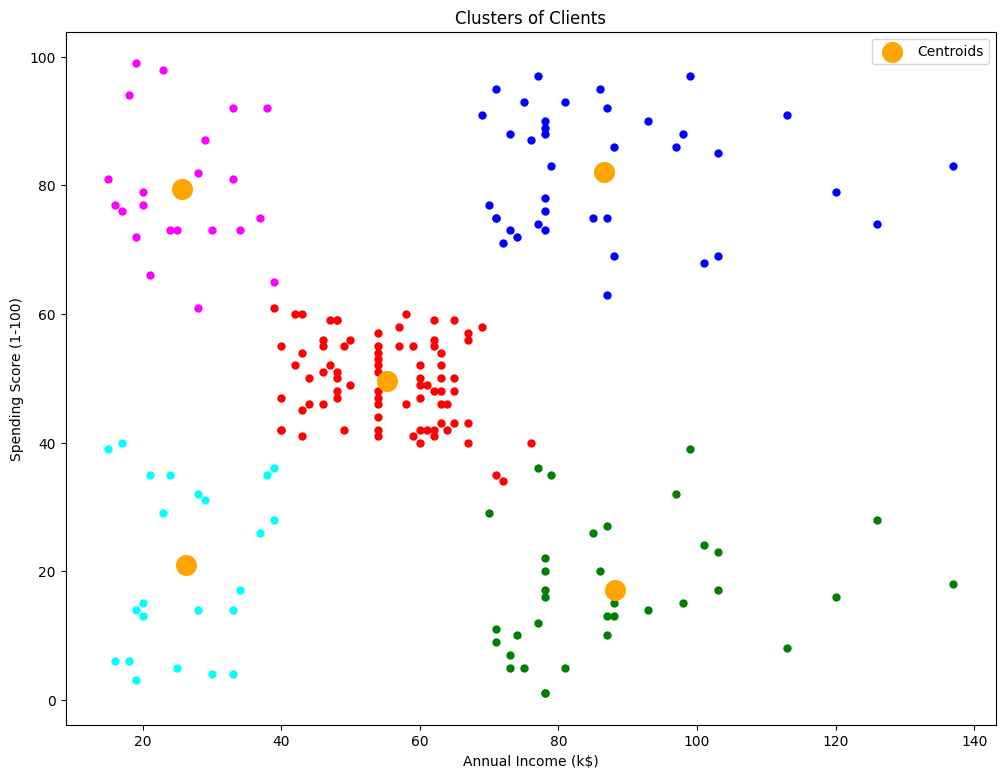

In [ ]:
point_size = 25
colors = ['red', 'blue', 'green', 'cyan', 'magenta']


plt.figure(figsize = (12,9))
for i in range(5):
    plt.scatter(X[kmeans_preds == i,0], X[kmeans_preds == i,1], s = point_size,
                c = colors[i], )

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 200,
            c = 'orange', label = 'Centroids')
plt.title('Clusters of Clients')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc = 'best')
plt.show()

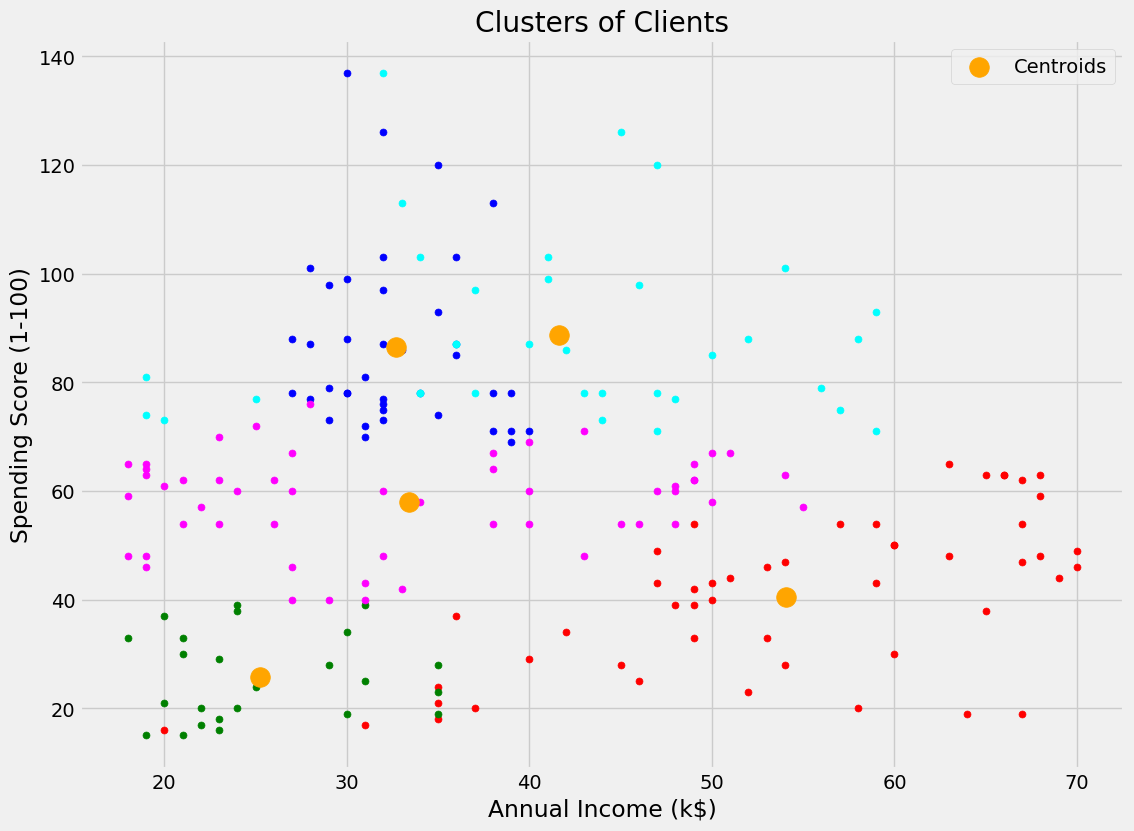

In [ ]:
point_size = 25
colors = ['red', 'blue', 'green', 'cyan', 'magenta']


plt.figure(figsize = (12,9))
for i in range(5):
    plt.scatter(X[kmeans_preds1 == i,0], X[kmeans_preds1 == i,1], s = point_size,
                c = colors[i], )

plt.scatter(kmeans1.cluster_centers_[:,0], kmeans1.cluster_centers_[:,1], s = 200,
            c = 'orange', label = 'Centroids')
plt.title('Clusters of Clients')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc = 'best')
plt.show()

In [ ]:
#menambahkan hasil clustering ke dalam dataframe
df['Cluster'] = kmeans_preds
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,ClusterMultiFeatures
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,5,5
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,5,5
4,5,Female,31,17,40,4,4
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,2,2
196,197,Female,45,126,28,1,1
197,198,Male,32,126,74,2,2
198,199,Male,32,137,18,1,1


In [ ]:
df.to_csv('mall_customers_with_clusters.csv', index=False)
print('DataFrame `df` (with cluster assignments) saved to mall_customers_with_clusters.csv')

DataFrame `df` (with cluster assignments) saved to mall_customers_with_clusters.csv


In [ ]:
data_cluster1.to_csv('data_cluster1.csv', index=False)
print('DataFrame `data_cluster1` saved to data_cluster1.csv')

DataFrame `data_cluster1` saved to data_cluster1.csv


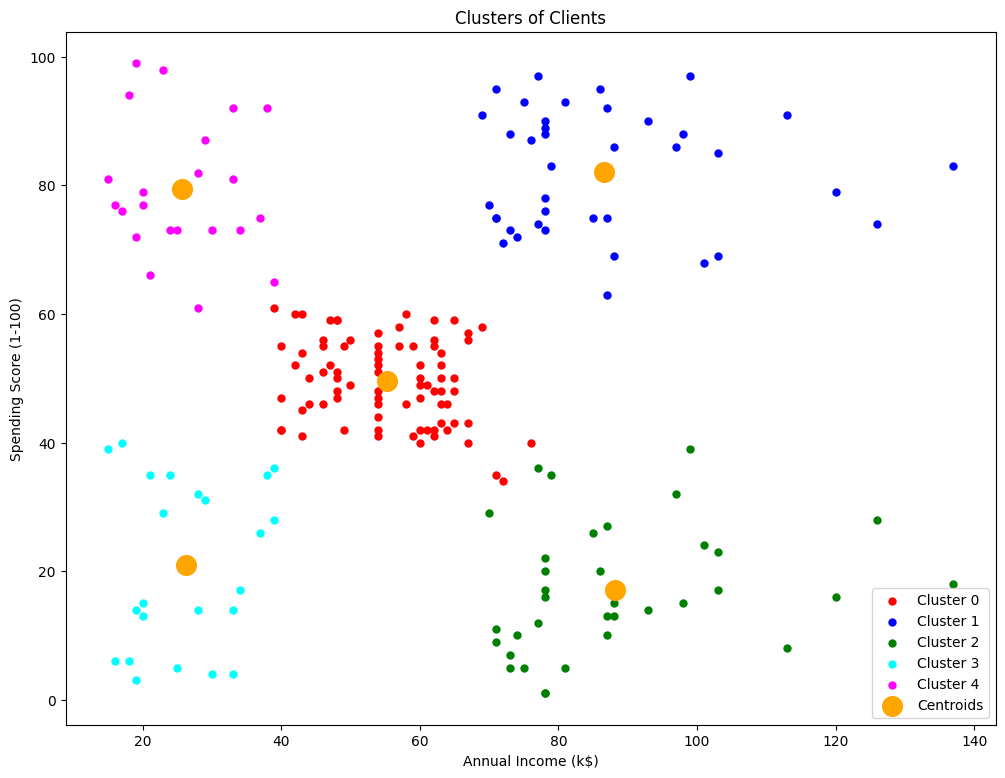

In [ ]:
point_size = 25
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}

plt.figure(figsize = (12,9))
for i in range(5):
    plt.scatter(X[kmeans_preds == i,0], X[kmeans_preds == i,1], s = point_size,
                c = colors[i], label=cluster_names.get(i, f'Cluster {i}') )

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 200,
            c = 'orange', label = 'Centroids')
plt.title('Clusters of Clients')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc = 'best')
plt.show()

In [ ]:
df.groupby(['Cluster'])['Cluster'].count()

,Cluster
Cluster,
0,81
1,39
2,35
3,23
4,22


In [ ]:
#menampilkan cluster tertentu
data_cluster1=df.loc[df['Cluster'] == 1]

In [ ]:
data_cluster1

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
123,124,Male,39,69,91,1
125,126,Female,31,70,77,1
127,128,Male,40,71,95,1
129,130,Male,38,71,75,1
131,132,Male,39,71,75,1
133,134,Female,31,72,71,1
135,136,Female,29,73,88,1
137,138,Male,32,73,73,1
139,140,Female,35,74,72,1
141,142,Male,32,75,93,1


### **Menentukan Jumlah Cluster Optimal**

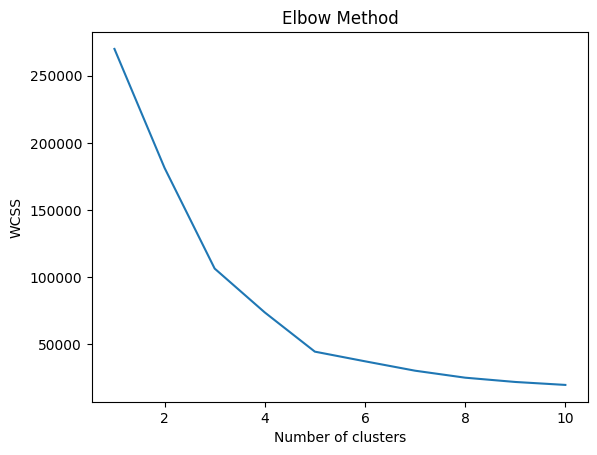

In [ ]:
#Method 1 - Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

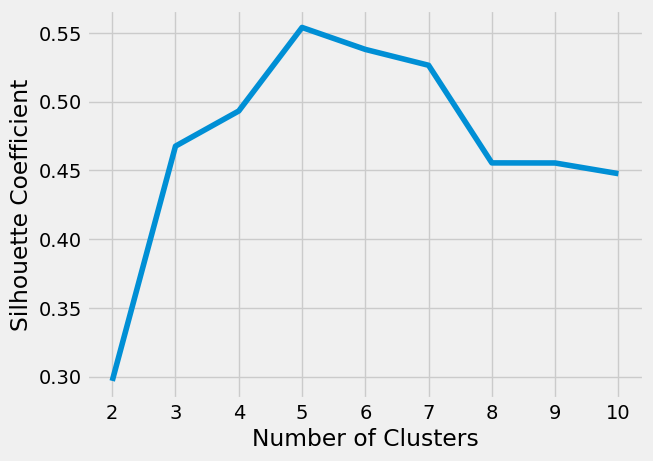

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

### **Clustering Multi Fitur**

In [ ]:
import plotly as py
import plotly.graph_objs as go

In [ ]:
X = np.array(df.iloc[:,[2,3,4]])

In [ ]:
X[:5]

array([[19, 15, 39],
       [21, 15, 81],
       [20, 16,  6],
       [23, 16, 77],
       [31, 17, 40]])

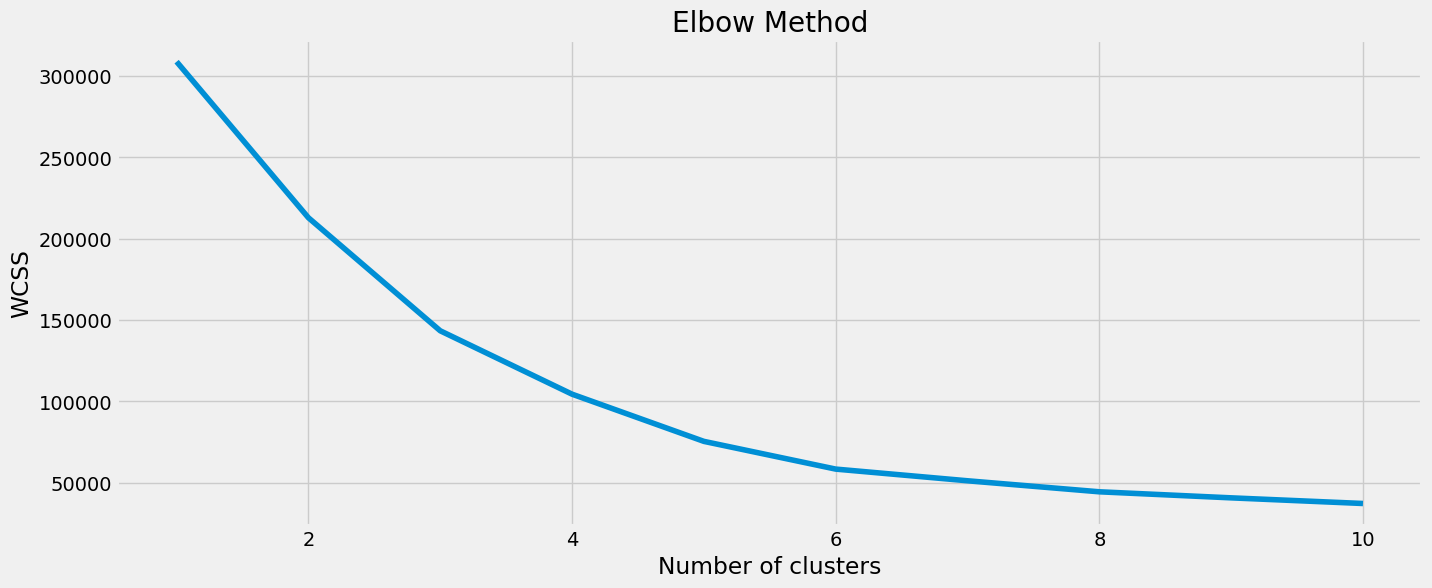

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(1 , figsize = (15 ,6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

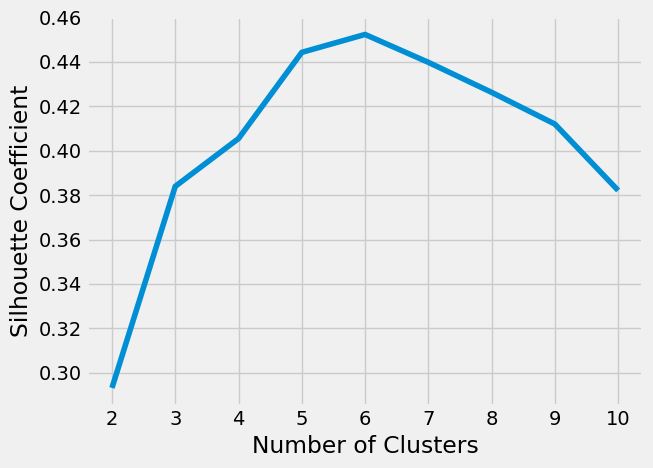

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

**Create Cluster**

In [ ]:
kmeans = KMeans(n_clusters = 6, max_iter = 500, n_init = 10, random_state = 0)
kmeans_preds = kmeans.fit_predict(X)

In [ ]:
#predict result
kmeans_preds

array([4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5,
       4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 3, 5, 3, 0,
       4, 5, 3, 0, 0, 0, 3, 0, 0, 3, 3, 3, 3, 3, 0, 3, 3, 0, 3, 3, 3, 0,
       3, 3, 0, 0, 3, 3, 3, 3, 3, 0, 3, 0, 0, 3, 3, 0, 3, 3, 0, 3, 3, 0,
       0, 3, 3, 0, 3, 0, 0, 0, 3, 0, 3, 0, 0, 3, 3, 0, 3, 0, 3, 3, 3, 3,
       3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [ ]:
# Menampilkan pusat cluster
print(kmeans.cluster_centers_)

[[27.         56.65789474 49.13157895]
 [41.68571429 88.22857143 17.28571429]
 [32.69230769 86.53846154 82.12820513]
 [56.15555556 53.37777778 49.08888889]
 [44.14285714 25.14285714 19.52380952]
 [25.27272727 25.72727273 79.36363636]]


In [ ]:
import plotly.graph_objs as go
import plotly.offline as py

# =========================
# Ambil label & centroid
# =========================
labels3 = kmeans.labels_
centroids3 = kmeans.cluster_centers_

df['ClusterMultiFeatures'] = labels3

# =========================
# Trace data (titik cluster)
# =========================
trace_data = go.Scatter3d(
    x=df['Age'],
    y=df['Spending Score (1-100)'],
    z=df['Annual Income (k$)'],
    mode='markers',
    marker=dict(
        color=df['ClusterMultiFeatures'],
        size=8,
        colorscale='Viridis',
        opacity=0.7
    ),
    name='Data Points'
)

# =========================
# Trace centroid
# =========================
trace_centroid = go.Scatter3d(
    x=centroids3[:, 0],   # Age
    y=centroids3[:, 1],   # Spending Score
    z=centroids3[:, 2],   # Annual Income
    mode='markers+text',
    marker=dict(
        color='red',
        size=14,
        symbol='diamond'
    ),
    text=[f'C{i}' for i in range(len(centroids3))],
    textposition='top center',
    name='Centroids'
)

# =========================
# Layout
# =========================
layout = go.Layout(
    title='3D Visualization of K-Means Clustering with Centroids',
    scene=dict(
        xaxis=dict(title='Age'),
        yaxis=dict(title='Spending Score (1-100)'),
        zaxis=dict(title='Annual Income (k$)')
    ),
    legend=dict(x=0.02, y=0.98)
)

# =========================
# Render
# =========================
fig = go.Figure(data=[trace_data, trace_centroid], layout=layout)
py.iplot(fig)